In [ ]:
import os

print(os.listdir())


['.config', 'Dataset .csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df[['Restaurant Name',
    'Cuisines',
    'Price range',
    'Aggregate rating']].head()

,Restaurant Name,Cuisines,Price range,Aggregate rating
0,Le Petit Souffle,"French, Japanese, Desserts",3,4.8
1,Izakaya Kikufuji,Japanese,3,4.5
2,Heat - Edsa Shangri-La,"Seafood, Asian, Filipino, Indian",4,4.4
3,Ooma,"Japanese, Sushi",4,4.9
4,Sambo Kojin,"Japanese, Korean",4,4.8


In [ ]:
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

print(df['Cuisines'].isnull().sum())

0


In [ ]:
print(df['Cuisines'].value_counts().head(10))

Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [ ]:
def recommend_restaurants(cuisine, price_range):

    recommendations = df[
        (df['Cuisines'].str.contains(cuisine, case=False, na=False)) &
        (df['Price range'] == price_range)
    ]

    recommendations = recommendations.sort_values(
        by='Aggregate rating',
        ascending=False
    )

    return recommendations[
        ['Restaurant Name',
         'Cuisines',
         'Aggregate rating',
         'Price range']
    ].head(10)

In [ ]:
recommend_restaurants(
    cuisine='North Indian',
    price_range=2
)

,Restaurant Name,Cuisines,Aggregate rating,Price range
9394,Dishoom,"Indian, North Indian, Curry, Cafe",4.7,2
734,ECHOES Koramangala,"Continental, American, Italian, North Indian, ...",4.7,2
2407,India Restaurant,"Biryani, North Indian, Chinese, Mughlai",4.6,2
2456,Aman Chicken,"North Indian, Mughlai",4.6,2
6426,Food Scouts,"North Indian, Chinese, Continental",4.6,2
4206,Midnight Hunger Hub,"North Indian, Fast Food, Italian, Asian",4.5,2
6706,Ghar Bistro Cafe,"Continental, North Indian, Chinese, Mughlai, A...",4.4,2
818,Palmshore,"North Indian, Mughlai, Chinese, South Indian",4.4,2
9162,Kargo,"Charcoal Grill, Italian, North Indian, Europea...",4.4,2
9194,Saffron Mantra,"North Indian, Chinese",4.4,2


In [ ]:
import matplotlib.pyplot as plt

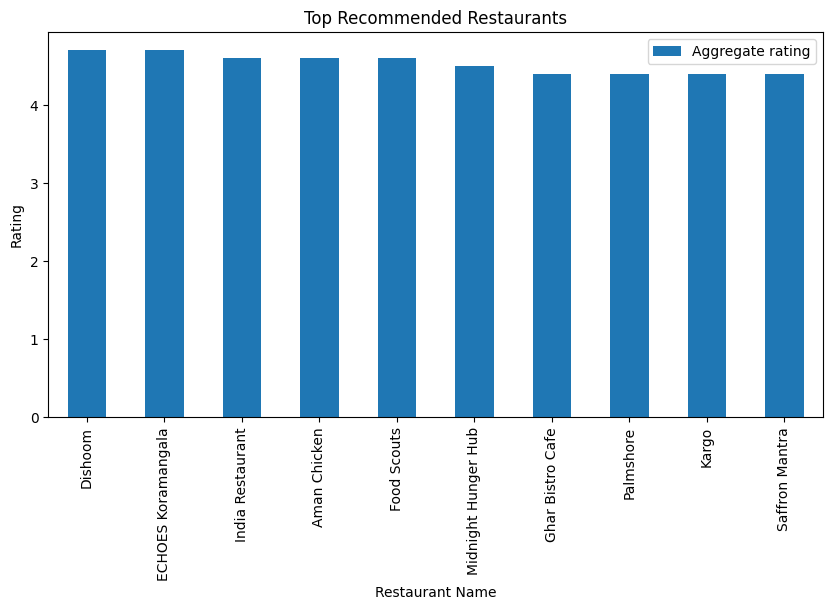

In [ ]:
top_restaurants = recommend_restaurants(
    cuisine='North Indian',
    price_range=2
)

top_restaurants.plot(
    x='Restaurant Name',
    y='Aggregate rating',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Recommended Restaurants")
plt.ylabel("Rating")
plt.show()